# 01 Rl Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply RL to games, control, or recommendation
- Identify reward design and environment interfaces

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson shows students where reinforcement learning appears outside toy benchmarks.

The main goal is to help them recognize which real-world problems fit the RL pattern and which ones do not.

Why this matters: students should not leave the course thinking RL is only for games.

This notebook gives the application lens for the rest of Unit 5.

## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the opening application overview before the coding sections.

Why this pick:
- Clear Australian accent and practical explanation of where RL is actually used.
- Connects theory to games, robotics, trading, and control tasks.
- Good for widening student intuition beyond benchmark environments.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Application lens: translating a real task into RL.
- Objective: what success really means.
- Constraint: a real-world limit.
- Deployment gap: toy example versus real system.
- Reward misspecification: when the designed reward does not match the true goal.

### Quick Check
- How do states, actions, and rewards map to the real problem?
- Why is reward design harder in applications?
- What makes an application realistic?
- What can go wrong even if the agent optimizes the reward successfully?

### Common Mistakes
- Choosing an algorithm before formulating the problem.
- Ignoring constraints.
- Optimizing a proxy that is not the real goal.
- Forgetting that a system can maximize reward and still behave badly in practice.


## Big Idea

By Unit 5, the question is no longer only *how an RL algorithm works*.

Now the question becomes:

- where is RL actually useful?
- how do we formulate real applications?
- what makes deployment difficult in practice?

## Application Framing Before Algorithm Choice

One of the biggest mistakes in advanced RL is asking:

`Which algorithm should I use?`

before asking:

`Is this really an RL problem, and how should I formulate it?`

### The right order

1. define the state
2. define the actions
3. define the reward
4. identify constraints and safety risks
5. only then discuss algorithms

### Why this matters

In real systems, poor formulation can ruin the project even if the learning algorithm is mathematically correct.

A badly chosen reward can produce harmful behavior, and a missing constraint can make deployment unsafe.

### Teaching takeaway

Unit 5 is not only about seeing more examples.
It is about learning how to think like a designer of RL systems, not only a user of RL algorithms.

## Application Lens

For each application, ask five questions:

1. What is the state?
2. What actions are available?
3. What reward is optimized?
4. What makes the environment difficult?
5. What safety or ethical risks appear?

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Assign/update a variable used later in this cell or in other cells.
applications = {
    # Execute: "games": {
    "games": {
        # Execute: "state": "board position or observation frame",
        "state": "board position or observation frame",
        # Execute: "action": "move or control command",
        "action": "move or control command",
        # Execute: "reward": "score, win signal, survival",
        "reward": "score, win signal, survival",
        # Execute: "challenge": "long horizons and sparse rewards",
        "challenge": "long horizons and sparse rewards",
    # Execute: },
    },
    # Execute: "robotics": {
    "robotics": {
        # Execute: "state": "joint positions, velocities, sensor readings",
        "state": "joint positions, velocities, sensor readings",
        # Execute: "action": "motor torques or control commands",
        "action": "motor torques or control commands",
        # Execute: "reward": "stability, speed, task completion",
        "reward": "stability, speed, task completion",
        # Execute: "challenge": "safety and sim-to-real transfer",
        "challenge": "safety and sim-to-real transfer",
    # Execute: },
    },
    # Execute: "recommendation": {
    "recommendation": {
        # Execute: "state": "user context and interaction history",
        "state": "user context and interaction history",
        # Execute: "action": "item or content recommendation",
        "action": "item or content recommendation",
        # Execute: "reward": "click, watch time, conversion, retention",
        "reward": "click, watch time, conversion, retention",
        # Execute: "challenge": "delayed rewards and user feedback loops",
        "challenge": "delayed rewards and user feedback loops",
    # Execute: },
    },
    # Execute: "resource optimization": {
    "resource optimization": {
        # Execute: "state": "current demand, supply, system load",
        "state": "current demand, supply, system load",
        # Execute: "action": "allocation or scheduling decision",
        "action": "allocation or scheduling decision",
        # Execute: "reward": "efficiency, cost reduction, throughput",
        "reward": "efficiency, cost reduction, throughput",
        # Execute: "challenge": "constraints and changing conditions",
        "challenge": "constraints and changing conditions",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Loop header: repeat the indented block for each item in the iterable.
for name, details in applications.items():
    # Print text to the notebook cell output (console).
    print(f"\nApplication: {name}")
    # Loop header: repeat the indented block for each item in the iterable.
    for key, value in details.items():
        # Print text to the notebook cell output (console).
        print(f"  {key.title()}: {value}")



Application: games
  State: board position or observation frame
  Action: move or control command
  Reward: score, win signal, survival
  Challenge: long horizons and sparse rewards

Application: robotics
  State: joint positions, velocities, sensor readings
  Action: motor torques or control commands
  Reward: stability, speed, task completion
  Challenge: safety and sim-to-real transfer

Application: recommendation
  State: user context and interaction history
  Action: item or content recommendation
  Reward: click, watch time, conversion, retention
  Challenge: delayed rewards and user feedback loops

Application: resource optimization
  State: current demand, supply, system load
  Action: allocation or scheduling decision
  Reward: efficiency, cost reduction, throughput
  Challenge: constraints and changing conditions


## Which applications fit RL best?

RL is strongest when:

- decisions are sequential
- actions change future states
- feedback arrives over time
- a fixed supervised label is not enough

RL is weaker when the problem is one-shot, fully labeled, or unsafe to explore directly.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Assign/update a variable used later in this cell or in other cells.
scores = {
    # Execute: "games": 5,
    "games": 5,
    # Execute: "robotics": 4,
    "robotics": 4,
    # Execute: "recommendation": 4,
    "recommendation": 4,
    # Execute: "resource optimization": 5,
    "resource optimization": 5,
    # Execute: "static image classification": 1,
    "static image classification": 1,
# Part of a dict/set literal layout (syntax grouping).
}

# Print text to the notebook cell output (console).
print("Sequential-decision suitability score (1=weak, 5=strong):")
# Loop header: repeat the indented block for each item in the iterable.
for name, score in scores.items():
    # Print text to the notebook cell output (console).
    print(f"- {name}: {score}")


Sequential-decision suitability score (1=weak, 5=strong):
- games: 5
- robotics: 4
- recommendation: 4
- resource optimization: 5
- static image classification: 1


## Common deployment risks

Before deploying RL in the real world, check for:

- reward hacking
- unsafe exploration
- unfair or manipulative behavior
- poor robustness under shift
- misleading evaluation metrics

## Worked Comparison

The short case study below is not about mastering one algorithm.
It is about seeing how the same RL thinking pattern appears across domains.

## Worked Example: Comparing Application Formulations

Below we compare three application domains at the formulation level:

- recommendation
- robotics
- inventory/resource optimization

The goal is to understand the *problem framing* before choosing the algorithm.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Assign/update a variable used later in this cell or in other cells.
application_table = [
    # Execute: ["Recommendation", "user profile + history", "recommend item", "engagement / retention", " …
    ["Recommendation", "user profile + history", "recommend item", "engagement / retention", "filter bubbles"],
    # Execute: ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe …
    ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe exploration"],
    # Execute: ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "re …
    ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "reward misspecification"],
# Execute: ]
]

# Assign/update a variable used later in this cell or in other cells.
headers = ["Domain", "State", "Action", "Reward", "Risk"]
# Print text to the notebook cell output (console).
print(" | ".join(headers))
# Print text to the notebook cell output (console).
print("-" * 120)
# Loop header: repeat the indented block for each item in the iterable.
for row in application_table:
    # Print text to the notebook cell output (console).
    print(" | ".join(row))

# Print text to the notebook cell output (console).
print("\nDiscussion prompt:")
# Print text to the notebook cell output (console).
print("Notice that the algorithm is not the first design decision.")
# Print text to the notebook cell output (console).
print("The first decision is how to represent the sequential decision problem well.")


Domain | State | Action | Reward | Risk
------------------------------------------------------------------------------------------------------------------------
Recommendation | user profile + history | recommend item | engagement / retention | filter bubbles
Robotics | robot state + sensors | motor command | task success + stability | unsafe exploration
Inventory | stock + demand signal | reorder decision | profit - cost - shortage | reward misspecification

Discussion prompt:
Notice that the algorithm is not the first design decision.
The first decision is how to represent the sequential decision problem well.


## Summary

This notebook is about **application thinking**.

### Main takeaways

- RL fits problems with sequential decisions and delayed consequences.
- The first design work is defining state, action, reward, and evaluation.
- Deployment risks matter as much as benchmark performance.
- Real applications often require safety, fairness, and robustness thinking before deployment.

### Next step

Continue to the later Unit 5 notebooks to study multi-agent RL, hierarchical RL,
and model-based RL as extensions of this application lens.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


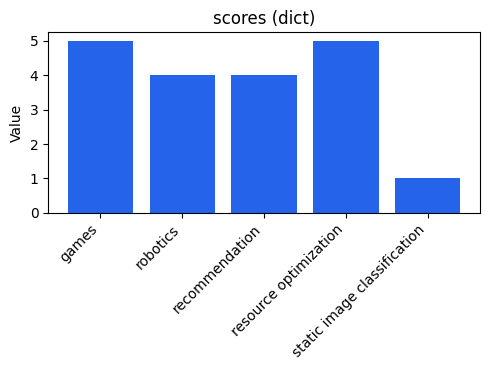

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Real RL applications begin by matching the problem structure to the right decision framework, constraints, and success metric.

**If students remember one idea:** An application is not automatically a good RL problem. Students must ask what is sequential, what is uncertain, and what feedback is available.

**Quick check before moving on:**
- Can you explain what makes a practical problem suitable for RL?
- Can you describe when a non-RL approach may actually be the better choice?

**Bridge to the next step:** The next lessons make this concrete through specific application areas such as games and resource allocation.
